In [1]:
from dcm_seg_nodules import extract_seg
import pydicom, numpy as np, matplotlib.pyplot as plt
import SimpleITK as sitk

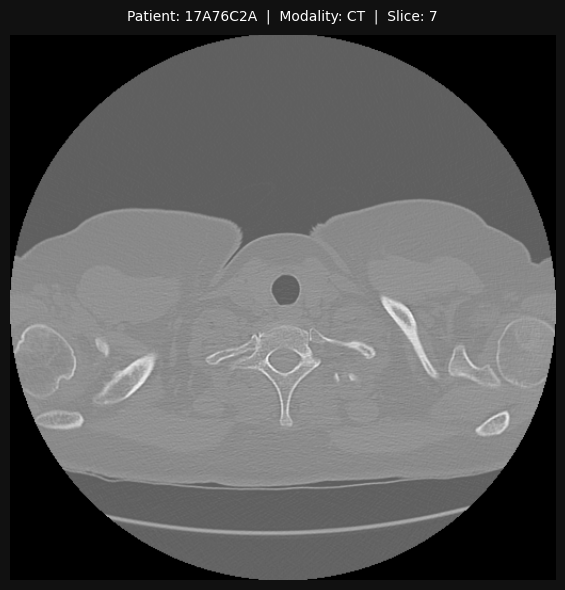

  Dimensions   : (512, 512)
  Pixel spacing: [0.664062, 0.664062]
  Study date   : 20210405
  Slice Thickness: 1.250000


In [3]:
def show_dicom(path: str):
    """Affiche une coupe DICOM avec ses métadonnées principales."""
    ds  = pydicom.dcmread(path)
    img = ds.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    fig, ax = plt.subplots(1, 1, figsize=(6, 6), facecolor="#111")
    ax.imshow(img, cmap="gray", interpolation="bilinear")
    ax.set_title(
        f"Patient: {getattr(ds,'PatientID','?')}  |  "
        f"Modality: {getattr(ds,'Modality','?')}  |  "
        f"Slice: {getattr(ds,'InstanceNumber','?')}",
        color="white", fontsize=10, pad=10
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    #print(ds)
    print(f"  Dimensions   : {img.shape}")
    print(f"  Pixel spacing: {getattr(ds,'PixelSpacing','N/A')}")
    print(f"  Study date   : {getattr(ds,'StudyDate','N/A')}")
    print(f"  Slice Thickness: {getattr(ds,'SliceThickness','N/A')}")
    return ds

import os

# ── Utilisation ───────────────────────────────────────
ds = show_dicom("./data/17A76C2A 17A76C2A/26721665 TC TRAX/CT 1.25mm Pulmn/CT000007.dcm")

In [26]:
# bsd =pydicom.dcmread("data/136F50A1 136F50A1/10492106 TC TRAX TC ABDOMEN TC PELVIS/SR Review Annotation SR by Philippe Michelon Feb122026 1903./SR000001.dcm")
# bsd

In [5]:
seg_path = extract_seg("./data/17A76C2A 17A76C2A/26721665 TC TRAX/CT 1.25mm Pulmn", output_dir="results")
print(f"SEG saved to: {seg_path}")
print(seg_path[0])
print("----------------------")
print(seg_path[1])


SEG saved to: (PosixPath('/Users/antoinedelaby/Desktop/Medical_agent/results/CT 1.25mm Pulmn/output-seg.dcm'), 'ID: 17A76C2A\nAccession Number: 26721665\nOriginal study: 1.2.840.113654.2.70.1.333333578606125611209251866158241086978\nOriginal Series: 1.2.840.113654.2.70.1.251872505507105532891396442385337654814\n\nSummary:\n- Finding1: diameter 2.6mm\n- Finding2: diameter 7.1mm\n- Finding3: diameter 12.4mm')
/Users/antoinedelaby/Desktop/Medical_agent/results/CT 1.25mm Pulmn/output-seg.dcm
----------------------
ID: 17A76C2A
Accession Number: 26721665
Original study: 1.2.840.113654.2.70.1.333333578606125611209251866158241086978
Original Series: 1.2.840.113654.2.70.1.251872505507105532891396442385337654814

Summary:
- Finding1: diameter 2.6mm
- Finding2: diameter 7.1mm
- Finding3: diameter 12.4mm


In [28]:
nb_lesions = "Number of nodules and their sizes: "+ seg_path[1][206:]
print(nb_lesions)

Number of nodules and their sizes: 
- Finding1: diameter 2.6mm
- Finding2: diameter 7.1mm
- Finding3: diameter 12.4mm


Image (0x119e59360)
  RTTI typeinfo:   itk::Image<unsigned char, 3u>
  Reference Count: 1
  Modified Time: 2401
  Debug: Off
  Object Name: 
  Observers: 
    none
  Source: (none)
  Source output name: (none)
  Release Data: Off
  Data Released: False
  Global Release Data: Off
  PipelineMTime: 2384
  UpdateMTime: 2397
  RealTimeStamp: 0 seconds 
  LargestPossibleRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 702]
  BufferedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 702]
  RequestedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 702]
  Spacing: [1, 1, 1]
  Origin: [-162.2, -147.9, 20.5]
  Direction: 
1 0 0
0 1 0
0 0 1

  IndexToPointMatrix: 
1 0 0
0 1 0
0 0 1

  PointToIndexMatrix: 
1 0 0
0 1 0
0 0 1

  Inverse Direction: 
1 0 0
0 1 0
0 0 1

  PixelContainer: 
    ImportImageContainer (0x119e4c220)
      RTTI typeinfo:   itk::ImportImageContainer<unsigned long, unsigned char>
      Reference Count: 1
      Modified Time

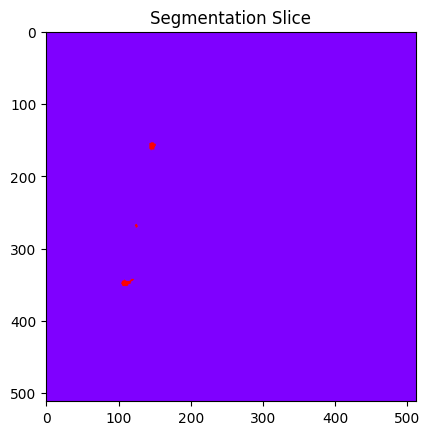

In [29]:
#s = show_dicom("./results/CT CEV torax/output-seg.dcm")

# Read the DICOM SEG file
seg_path = "./results/CT 1.25mm Pulmn/output-seg.dcm"
seg = sitk.ReadImage(seg_path)

print(seg)

# Print metadata
print("Image Size:", seg.GetSize())
print("Number of Segments:", seg.GetNumberOfComponentsPerPixel())

# Extract the first segment (assuming binary segmentation)
# segment = sitk.BinaryThreshold(seg, lowerThreshold=1, upperThreshold=)
segment_array = sitk.GetArrayFromImage(seg)

# Convert to numpy array for visualization
# segment_array = sitk.GetArrayFromImage(segment)

num = len(segment_array)

print(np.unique(segment_array))

# Plot a slice
plt.imshow(segment_array.max(axis=0), cmap='rainbow')
plt.title("Segmentation Slice")
plt.show()

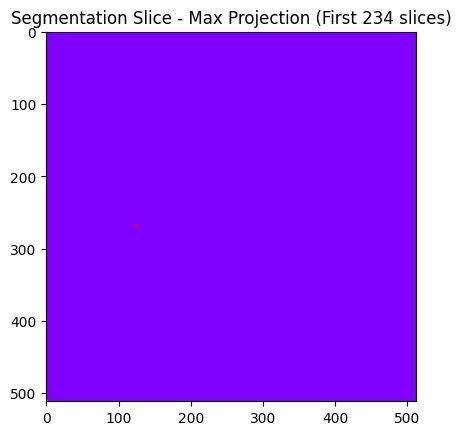

In [30]:
# Plot a slice - maximum projection of first 234 slices
plt.imshow(segment_array[:234].max(axis=0), cmap='rainbow')
plt.title("Segmentation Slice - Max Projection (First 234 slices)")
plt.show()

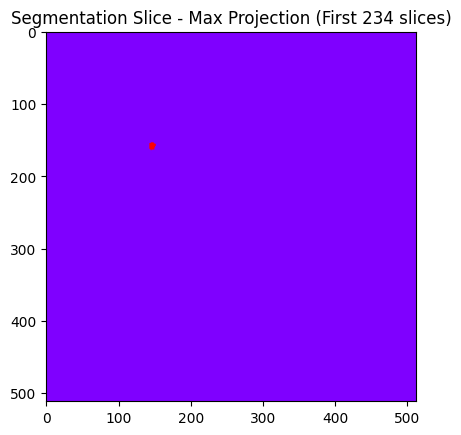

In [31]:
plt.imshow(segment_array[235:234*2].max(axis=0), cmap='rainbow')
plt.title("Segmentation Slice - Max Projection (First 234 slices)")
plt.show()

In [46]:
np.count_nonzero(segment_array == 255)

np.int64(382)

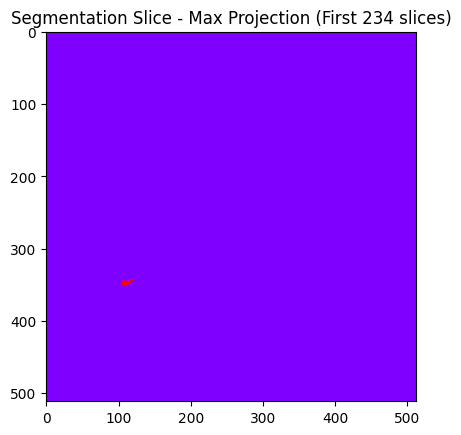

In [32]:
plt.imshow(segment_array[235*2+1:234*3].max(axis=0), cmap='rainbow')
plt.title("Segmentation Slice - Max Projection (First 234 slices)")
plt.show()

In [33]:
#segment_array.shape
#print(segment_array)
spacing = seg.GetSpacing()
print(spacing)

(1.0, 1.0, 1.0)


In [34]:
# Path to your DICOM file


# Read the DICOM file
ds2 = pydicom.dcmread(seg_path)
img2 = ds2.pixel_array.astype(bool)
print("Image shape:", img2.shape)

# Parameters
n = 234
itera = 0

# Extract a sub-volume
l1 = img2[n*itera : n*(itera+1)-1, :, :]
#print(l1)
# Flip along vertical axis
l1 = np.flipud(l1)

# Find index of maximum sum along first axis
max_index = np.argmax(l1.sum(axis=(1, 2)))
print("Index with max sum:", max_index)

# Example CT and segmentation info
CT_shape = (89, 512, 512)
print("CT shape example:", CT_shape)

# Segmentation output example
output_seg_shape = (512, 512,356)
print("Segmentation output shape example:", output_seg_shape)

# Example: extract first nodule
#first_nodule = output_seg_shape[0:199, :, :]
#print("First nodule shape example:", first_nodule.shape)

# Additional commented code for future use
# image_data = result.data  # directly available
# image = result.image      # lazy construction
# print(image)
# dcm_filepath = dcm[100]
# print(dcm)
# ds = show_dicom(dcm_path)
# print("Function show_dicom() ready ✓")

Image shape: (702, 512, 512)
Index with max sum: 184
CT shape example: (89, 512, 512)
Segmentation output shape example: (512, 512, 356)


In [ ]:
ds = pydicom.dcmread(seg_path)
ds.SliceThickness

AttributeError: 'FileDataset' object has no attribute 'SliceThickness'

In [ ]:
from scipy import ndimage
from collections import defaultdict

def compute_nodule_volumes(seg_path: str, pixel_spacing_xy=None, slice_thickness=None):
    """
    Compute the volume of each cancerous nodule from a DICOM SEG file.
    
    Parameters:
    -----------
    seg_path : str
        Path to the DICOM SEG file
    pixel_spacing_xy : float or tuple, optional
        Pixel spacing in x and y directions (mm). If tuple, (x, y). If None, tries to extract from DICOM.
    slice_thickness : float, optional
        Slice thickness in z direction (mm). If None, tries to extract from DICOM.
        
    Returns:
    --------
    dict : Dictionary with nodule IDs as keys and volumes (in mm³) as values
    labeled_array : numpy array with labeled connected components
    """
    # Read the segmentation image
    seg = sitk.ReadImage(seg_path)
    segment_array = sitk.GetArrayFromImage(seg)
    
    # Get pixel spacing from the image metadata
    spacing = seg.GetSpacing()  # Returns (z, y, x) spacing in mm
    
    # Try to extract spacing from DICOM SEG file
    if pixel_spacing_xy is None or slice_thickness is None:
        try:
            ds = pydicom.dcmread(seg_path)
            
            # Try to get pixel spacing from Per-frame Functional Groups Sequence
            if hasattr(ds, 'PerFrameFunctionalGroupsSequence') and len(ds.PerFrameFunctionalGroupsSequence) > 0:
                frame = ds.PerFrameFunctionalGroupsSequence[0]
                if hasattr(frame, 'PixelMeasuresSequence'):
                    pixel_measures = frame.PixelMeasuresSequence[0]
                    if hasattr(pixel_measures, 'PixelSpacing'):
                        ps = pixel_measures.PixelSpacing
                        pixel_spacing_x = float(ps[0])
                        pixel_spacing_y = float(ps[1])
                    else:
                        pixel_spacing_x = pixel_spacing_y = spacing[2] if spacing[2] != 1.0 else 0.943359
                    
                    if hasattr(pixel_measures, 'SliceThickness'):
                        slice_thickness = float(pixel_measures.SliceThickness)
                    elif hasattr(pixel_measures, 'SpacingBetweenSlices'):
                        slice_thickness = float(pixel_measures.SpacingBetweenSlices)
                    else:
                        slice_thickness = spacing[0] if spacing[0] != 1.0 else 1.0
                else:
                    # Fallback to spacing from SimpleITK
                    pixel_spacing_x = pixel_spacing_y = spacing[2] if spacing[2] != 1.0 else 0.943359
                    slice_thickness = spacing[0] if spacing[0] != 1.0 else 1.0
            else:
                # Try direct attributes
                if hasattr(ds, 'PixelSpacing') and ds.PixelSpacing:
                    ps = ds.PixelSpacing
                    pixel_spacing_x = float(ps[0])
                    pixel_spacing_y = float(ps[1])
                else:
                    pixel_spacing_x = pixel_spacing_y = spacing[2] if spacing[2] != 1.0 else 0.943359
                
                if hasattr(ds, 'SliceThickness') and ds.SliceThickness:
                    slice_thickness = float(ds.SliceThickness)
                else:
                    slice_thickness = spacing[0] if spacing[0] != 1.0 else 1.0
        except Exception as e:
            print(f"Warning: Could not read pixel spacing from DICOM: {e}")
            print("Using default spacing or provided values.")
            if pixel_spacing_xy is None:
                pixel_spacing_x = pixel_spacing_y = 0.943359  # Default from your example
            if slice_thickness is None:
                slice_thickness = 1.0
    
    # Handle provided spacing values
    if pixel_spacing_xy is not None:
        if isinstance(pixel_spacing_xy, (tuple, list)):
            pixel_spacing_x, pixel_spacing_y = pixel_spacing_xy
        else:
            pixel_spacing_x = pixel_spacing_y = pixel_spacing_xy
    
    if slice_thickness is None:
        slice_thickness = spacing[0] if spacing[0] != 1.0 else 1.0
    
    # Convert segmentation to binary (0 and 1)
    binary_mask = (segment_array == 255).astype(np.uint8)
    
    # Find connected components (each nodule is a separate component)
    # Structure for 3D connectivity (6-connectivity: faces only)
    structure = np.ones((3, 3, 3), dtype=np.int32)
    labeled_array, num_features = ndimage.label(binary_mask, structure=structure)
    
    print(f"Found {num_features} nodule(s)")
    print(f"Pixel spacing: X={pixel_spacing_x:.4f} mm, Y={pixel_spacing_y:.4f} mm, Z={slice_thickness:.4f} mm")
    
    # Calculate volume for each nodule
    voxel_volume = pixel_spacing_x * pixel_spacing_y * slice_thickness  # Volume of one voxel in mm³
    
    nodule_volumes = {}
    for nodule_id in range(1, num_features + 1):
        # Count voxels for this nodule
        voxel_count = np.sum(labeled_array == nodule_id)
        # Calculate volume in mm³
        volume_mm3 = voxel_count * voxel_volume
        nodule_volumes[f"Nodule_{nodule_id}"] = {
            'volume_mm3': volume_mm3,
            'volume_ml': volume_mm3 / 1000.0,  # Convert to milliliters
            'voxel_count': int(voxel_count)
        }
        print(f"  Nodule {nodule_id}: {volume_mm3:.2f} mm³ ({volume_mm3/1000:.4f} ml), {voxel_count} voxels")
    
    return nodule_volumes, labeled_array

# Example usage
volumes, labeled = compute_nodule_volumes(seg_path)

Found 3 nodule(s)
Pixel spacing: X=0.6641 mm, Y=0.6641 mm, Z=1.2500 mm
  Nodule 1: 12.13 mm³ (0.0121 ml), 22 voxels
  Nodule 2: 74.97 mm³ (0.0750 ml), 136 voxels
  Nodule 3: 123.47 mm³ (0.1235 ml), 224 voxels


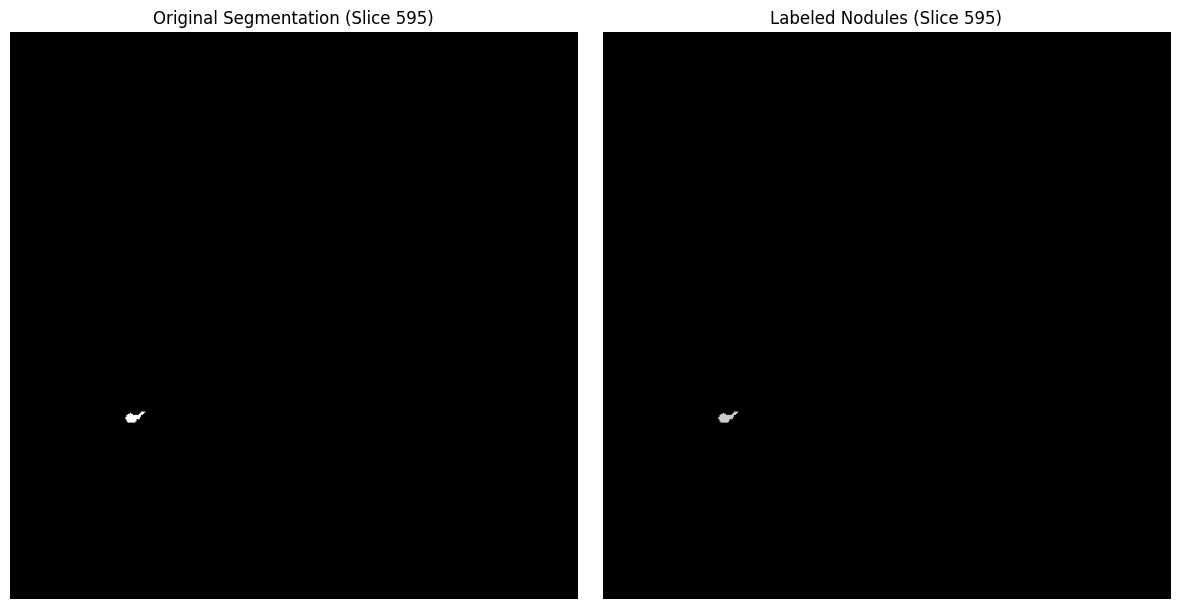


=== Volume Summary ===
Nodule_1:
  Volume: 12.13 mm³ (0.0121 ml)
  Voxel count: 22

Nodule_2:
  Volume: 74.97 mm³ (0.0750 ml)
  Voxel count: 136

Nodule_3:
  Volume: 123.47 mm³ (0.1235 ml)
  Voxel count: 224



In [ ]:
# Visualize the labeled nodules
if len(volumes) > 0:
    # Find a slice with nodules for visualization
    max_slice = np.argmax(np.sum(labeled > 0, axis=(1, 2)))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Original segmentation
    axes[0].imshow(segment_array[max_slice], cmap='gray')
    axes[0].set_title(f'Original Segmentation (Slice {max_slice})')
    axes[0].axis('off')
    
    # Labeled nodules (each nodule has a different color)
    axes[1].imshow(labeled[max_slice], cmap='nipy_spectral')
    axes[1].set_title(f'Labeled Nodules (Slice {max_slice})')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n=== Volume Summary ===")
    for nodule_id, info in volumes.items():
        print(f"{nodule_id}:")
        print(f"  Volume: {info['volume_mm3']:.2f} mm³ ({info['volume_ml']:.4f} ml)")
        print(f"  Voxel count: {info['voxel_count']}")
        print()
else:
    print("No nodules found in the segmentation.")